# Notebook 5.1: Convolutions

In this notebook we will explore the 2D convolution and cross-correlation operations on an image of a cat.

In [8]:
!wget -q -nc -O cat.jpg "https://www.dropbox.com/scl/fi/vc3j08yctlosvpr57v2ot/cat.jpg?rlkey=nbgc9klg8wlgkfewk08ln72xf&dl=1"

In [9]:
from imageio.v3 import imread, imwrite
from skimage.transform import rescale
from scipy.ndimage import convolve, correlate
from skimage.color import rgb2gray
from matplotlib import pyplot as plt
import numpy as np

Let's first load the cat image using `imageio.imread`.

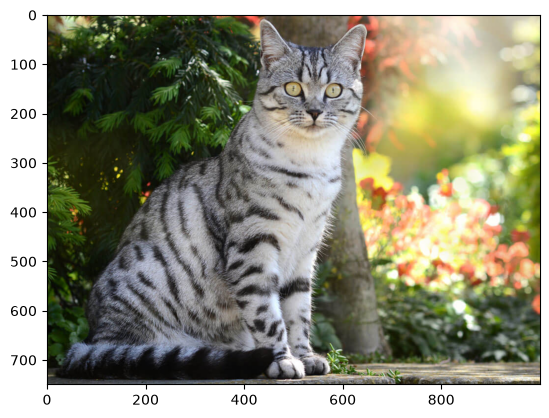

In [10]:
img = imread('cat.jpg')
plt.imshow(img)

The shape of the image is (H,W,C) -- height, width, channels -- and the data type is 8-bit unsigned integer.

In [11]:
img.shape, img.dtype

((750, 1000, 3), dtype('uint8'))

In [12]:
img[0,0]

array([132,  97,  43], dtype=uint8)

Let's resize the image so it is a bit easier to work with.

In [13]:
img = rescale(img, 0.5, anti_aliasing=True, channel_axis=-1)

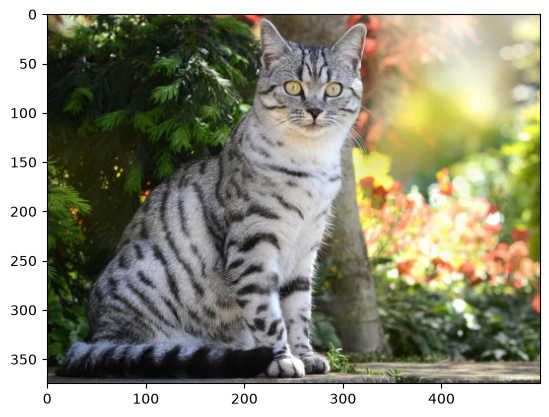

In [14]:
plt.imshow(img)
plt.show()

In [15]:
img.shape, img.dtype

((375, 500, 3), dtype('float64'))

In [16]:
img[0,0]

array([0.52809619, 0.40359118, 0.17732866])

Now let's convert to grayscale.

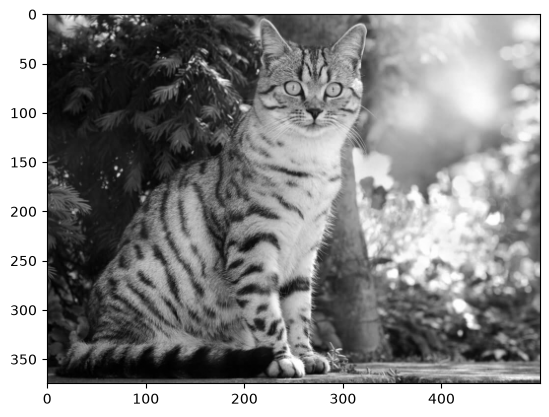

In [17]:
gray = rgb2gray(img)
plt.imshow(gray,cmap='gray')

Now the image has a single channel and is in 32-bit floating point.

In [18]:
gray.shape, gray.dtype

((375, 500), dtype('float64'))

In [19]:
gray[0,0]

np.float64(0.4137349680090368)

## Applying convolutional filters

Let's make a vertical edge filter as described in class.

In [20]:
dIdx = np.array([[-1, 0, 1]])

(np.float64(-0.5), np.float64(2.5), np.float64(0.5), np.float64(-0.5))

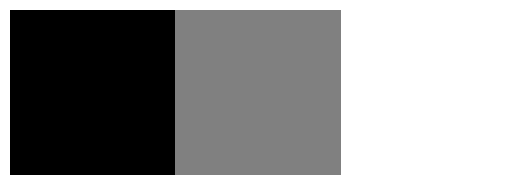

In [42]:
plt.imshow(dIdx,cmap='gray')
plt.axis('off')

To apply it to the image, we can use either `convolve` or `correlate`.

In [22]:
dIdx_convolve = convolve(gray,dIdx)
dIdx_correlate = correlate(gray,dIdx)

Text(0.5, 1.0, 'Correlation')

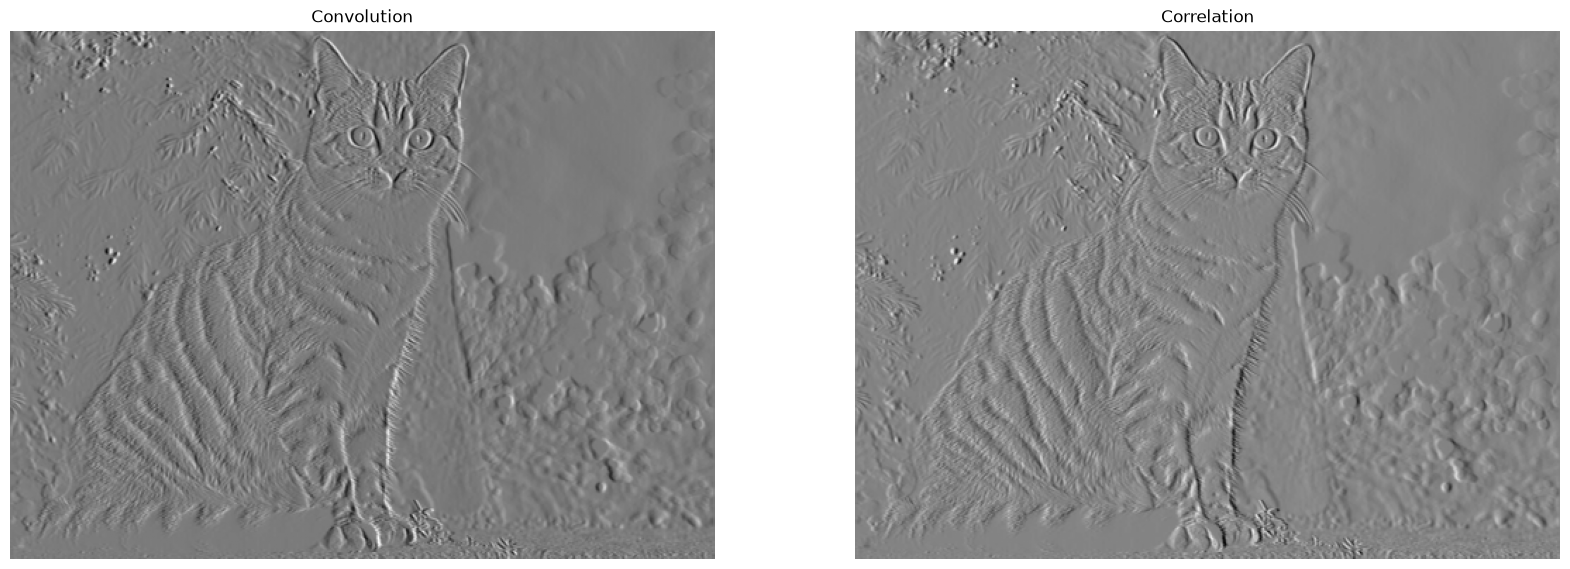

In [23]:
fig,axes = plt.subplots(1,2,figsize=(20,10))
axes[0].imshow(dIdx_convolve,cmap='gray')
axes[0].axis('off')
axes[0].set_title('Convolution')
axes[1].imshow(dIdx_correlate,cmap='gray')
axes[1].axis('off')
axes[1].set_title('Correlation')

Looking at the top left corner of the filter responses:

In [24]:
dIdx_convolve[:3,:3]

array([[-0.07364572, -0.10083385,  0.01049286],
       [-0.05640436, -0.09539044, -0.03540619],
       [-0.04607864, -0.09251003, -0.06271954]])

In [25]:
dIdx_correlate[:3,:3]

array([[ 0.07364572,  0.10083385, -0.01049286],
       [ 0.05640436,  0.09539044,  0.03540619],
       [ 0.04607864,  0.09251003,  0.06271954]])

The filter responses are equal but flipped in sign.  This is because the convolution operation horizontally and vertically flips the filter before applying it.  In this case, the horizontally flipped filter is a negated version of the original.

### Exercises

1. Let's explore how the correlation filter acts as a pattern detector.

These coordinates specify a box around the cat's face:

- Top, Left: (0,205)
- Bottom, Right: (128,325)

Crop the `gray` image to this box and show the result.  It should show just the cat's face.

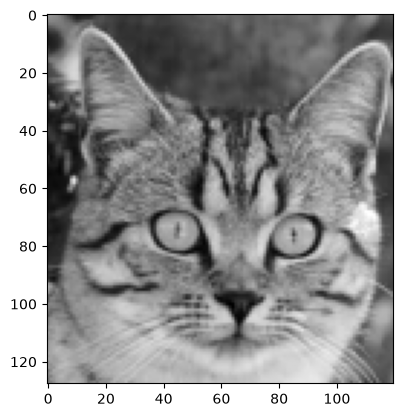

In [26]:
cat_topleft =  [0,205]
cat_bottomright = [128,325]
cat_crop = gray[cat_topleft[0]:cat_bottomright[0],cat_topleft[1]:cat_bottomright[1]]
plt.imshow(cat_crop,cmap='gray')

2. To turn the cat face into a filter subtract the mean from the cropped image.

Print out the mean of the filter to verify that it is zero.

In [27]:
cat_filter = cat_crop - cat_crop.mean()
cat_filter.mean()

np.float64(2.2204460492503132e-17)

3. Apply the cropped image to the original `gray` image as a correlation filter and show the result.

You should see a bright spot at the location of middle of the cat's face.  Why?

In [28]:
result = correlate(gray,cat_filter)

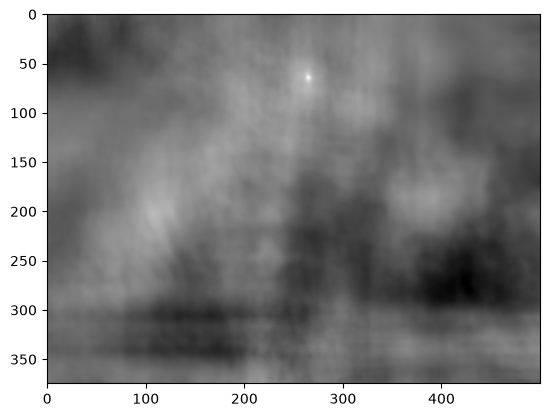

In [29]:
plt.imshow(result,cmap='gray')

The correlation filter acts as a local dot product, meaning that the response will be maximized when the image window looks most similar to the filter.

4. Now let's crop one of the eyes and see how that well that works as an eye detector.



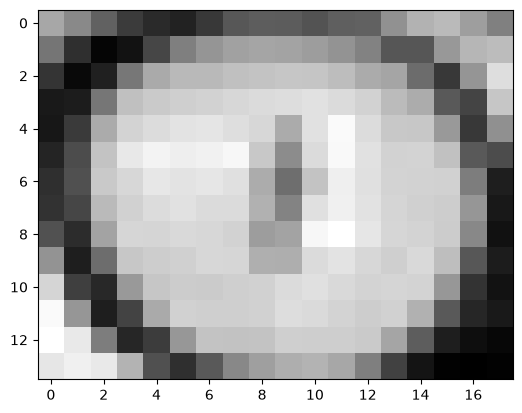

In [30]:
left_eye_topleft =  [68,241]
left_eye_bottomright = [82,259]
left_eye_crop = gray[left_eye_topleft[0]:left_eye_bottomright[0],left_eye_topleft[1]:left_eye_bottomright[1]]
plt.imshow(left_eye_crop,cmap='gray')

In [31]:
left_eye_filter = left_eye_crop - left_eye_crop.mean()
left_eye_filter.mean()

np.float64(4.4056469231157e-18)

In [32]:
result = correlate(gray,left_eye_filter)

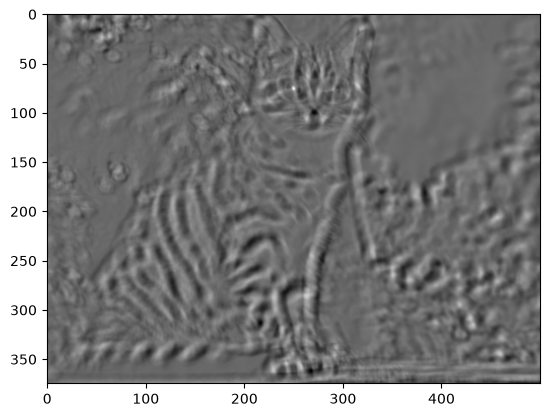

In [33]:
plt.imshow(result,cmap='gray')

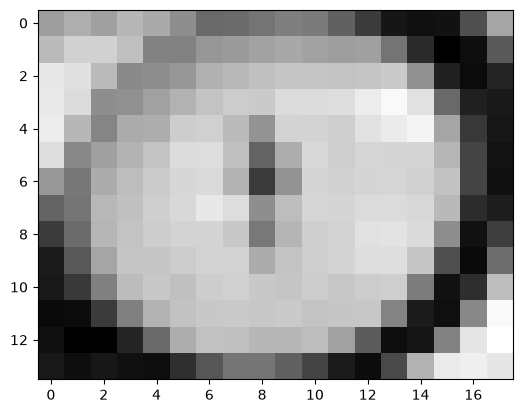

In [34]:
right_eye_topleft =  [70,282]
right_eye_bottomright = [84,300]
right_eye_crop = gray[right_eye_topleft[0]:right_eye_bottomright[0],right_eye_topleft[1]:right_eye_bottomright[1]]
plt.imshow(right_eye_crop,cmap='gray')

In [35]:
right_eye_crop.shape

(14, 18)

In [36]:
eye_filter = (left_eye_crop + right_eye_crop)/2
eye_filter -= eye_filter.mean()

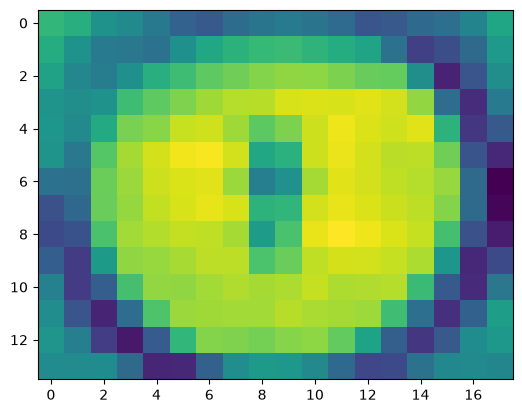

In [37]:
plt.imshow(eye_filter)

In [38]:
result = correlate(gray,eye_filter)

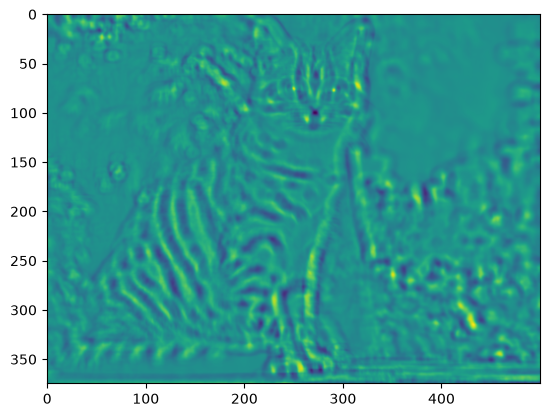

In [39]:
plt.imshow(result)